In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_DIR = Path("dataset_research")
if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        "Run this notebook from the Assignment3 folder containing dataset_research."
    )

pd.set_option("display.max_columns", 20)

In [2]:
bike = pd.read_csv(DATA_DIR / "bike-sharing" / "day.csv", parse_dates=["dteday"])
bike = bike.set_index("dteday").sort_index()
bike.index.name = "date"

print(f"Capital Bikeshare: {bike.shape[0]:,} rows, {bike.shape[1]} columns")
display(bike.head())

Capital Bikeshare: 731 rows, 15 columns


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
date,,,,,,,,,,,,,,,
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
sunspots = pd.read_csv(DATA_DIR / "sunspots.csv")
sunspots.index = pd.date_range("1749-01-01", periods=len(sunspots), freq="MS", name="date")
sunspots = sunspots.drop(columns=["rownames", "time"])

print(f"Sunspots: {sunspots.shape[0]:,} rows, {sunspots.shape[1]} column")
display(sunspots.head())

Sunspots: 2,820 rows, 1 column


,value
date,
1749-01-01,58.0
1749-02-01,62.6
1749-03-01,70.0
1749-04-01,55.7
1749-05-01,85.0


In [4]:
electricity = pd.read_csv(DATA_DIR / "usmelec.csv")
electricity.index = pd.date_range(
    "1973-01-01", periods=len(electricity), freq="MS", name="date"
)
electricity = electricity.drop(columns=["rownames", "time"])

print(f"US electricity: {electricity.shape[0]:,} rows, {electricity.shape[1]} column")
display(electricity.head())

US electricity: 486 rows, 1 column


,value
date,
1973-01-01,160.218
1973-02-01,143.539
1973-03-01,148.158
1973-04-01,139.589
1973-05-01,147.395


In [5]:
gasoline = pd.read_csv(DATA_DIR / "gasoline.csv")
gasoline = gasoline.drop(columns="rownames").set_index("time")
gasoline.index.name = "fractional_year"

print(f"US gasoline: {gasoline.shape[0]:,} rows, {gasoline.shape[1]} column")
display(gasoline.head())

US gasoline: 1,355 rows, 1 column


,value
fractional_year,
1991.100000,6.621
1991.119165,6.433
1991.138330,6.582
1991.157495,7.224
1991.176660,6.875


In [6]:
ett = pd.read_csv(DATA_DIR / "ETTh1.csv", parse_dates=["date"])
ett = ett.set_index("date").sort_index()

print(f"ETTh1: {ett.shape[0]:,} rows, {ett.shape[1]} columns")
display(ett.head())

ETTh1: 17,420 rows, 7 columns


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


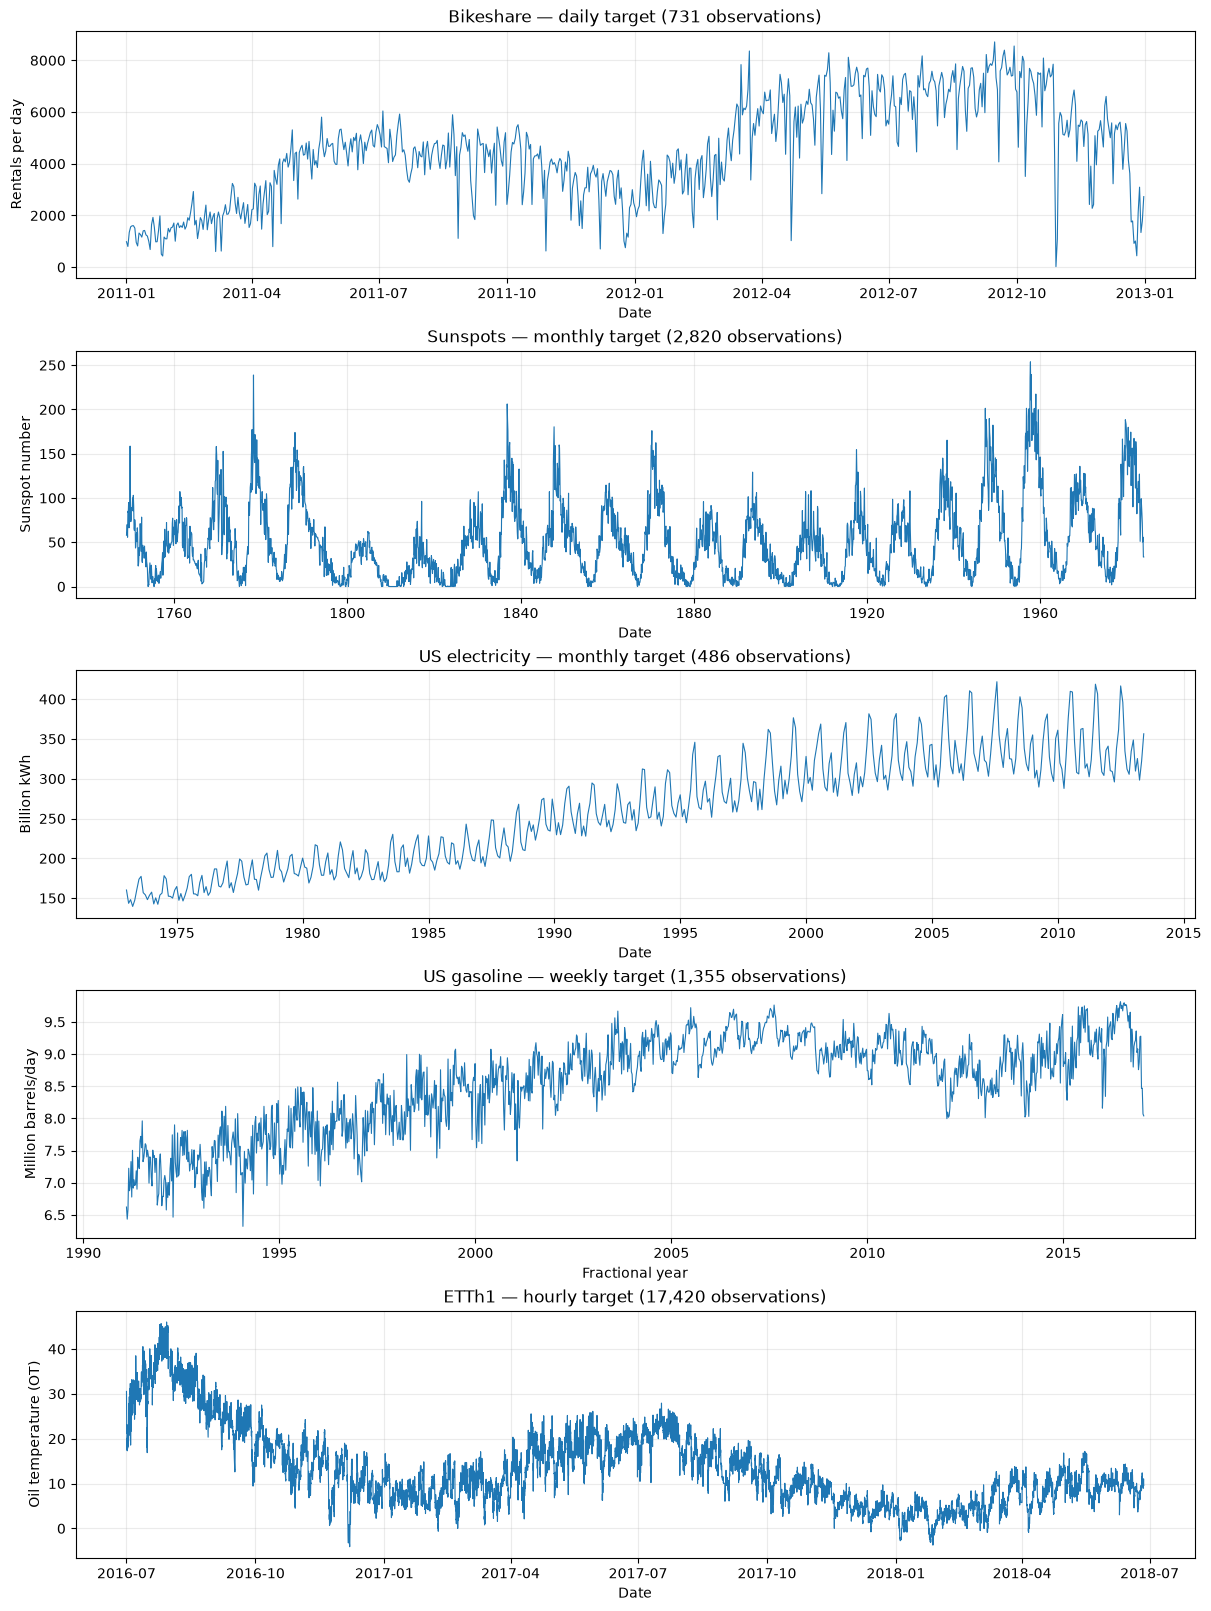

In [7]:
axis_labels = {
    "Bikeshare": "Rentals per day",
    "Sunspots": "Sunspot number",
    "US electricity": "Billion kWh",
    "US gasoline": "Million barrels/day",
    "ETTh1": "Oil temperature (OT)",
}

fig, axes = plt.subplots(5, 1, figsize=(12, 16), constrained_layout=True)
for ax, (name, series, frequency) in zip(axes, [
    ("Bikeshare", bike["cnt"], "daily"),
    ("Sunspots", sunspots["value"], "monthly"),
    ("US electricity", electricity["value"], "monthly"),
    ("US gasoline", gasoline["value"], "weekly"),
    ("ETTh1", ett["OT"], "hourly"),
]):
    ax.plot(series.index, series.to_numpy(), linewidth=0.8)
    ax.set_title(f"{name} — {frequency} target ({len(series):,} observations)")
    ax.set_ylabel(axis_labels[name])
    ax.set_xlabel("Fractional year" if name == "US gasoline" else "Date")
    ax.grid(alpha=0.25)
plt.show()